<a href="https://colab.research.google.com/github/aysh34/cpu-gpu-tpu-ml-benchmark/blob/main/DeFi_Fraud_Detection_CPU_vs_GPU_TPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hardware Comparison: CPU vs T4 GPU vs v5e‑1 TPU
## DeFi Fraud Detection with Random Forest and XGBoost

**Dataset:** DeFiTransLyzer (legitimate + fraud transactions)  
**Models:** Random Forest, XGBoost  
**Hardware:** CPU, T4 GPU, v5e‑1 TPU  
**Metrics:** Training Time, RAM Usage, Disk Usage, Accuracy, F1, Precision, Recall

---
**How to use this notebook:**
1. Run once with **Runtime > Change runtime type > None (CPU)**
2. Run again with **Runtime > Change runtime type > T4 GPU**
3. Run again with **Runtime > Change runtime type > v5e‑1 TPU**
4. After all three runs, run **Cell 9** and **Cell 10** to see comparison charts & speedup table.
5. Screenshot the **RAM/Disk bar** (top‑right sidebar) after each training cell.

In [1]:
# Install packages (including optional torch_xla for TPU)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "lightgbm", "xgboost", "cloud-tpu-client", "torch", "torch_xla", "-q"])

# Imports
import os, time, psutil, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import StratifiedKFold, GroupShuffleSplit, train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score, recall_score, average_precision_score,
                             precision_recall_curve, PrecisionRecallDisplay)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings("ignore")
print(f"Python {platform.python_version()} | XGB {xgb.__version__} | LGB {lgb.__version__}")

# Hardware detection (TPU, GPU, CPU)
def get_hardware():
    try:
        # Try to import torch_xla – if successful, TPU is available
        import torch_xla.core.xla_model as xm
        _ = xm.xla_device()  # initialise TPU
        hw = "TPU"
        print(f"TPU device: {xm.xla_device()}")
    except (ImportError, RuntimeError):
        if torch.cuda.is_available():
            hw = "GPU"
            print(f"GPU: {torch.cuda.get_device_name(0)}")
        else:
            hw = "CPU"
    vm = psutil.virtual_memory()
    disk = psutil.disk_usage("/")
    print(f"{hw} mode | RAM: {vm.used/1e9:.1f}/{vm.total/1e9:.1f} GB | Disk: {disk.used/1e9:.1f}/{disk.total/1e9:.1f} GB")
    return hw

HARDWARE = get_hardware()

# Mount Drive & load data
from google.colab import drive
drive.mount("/content/drive")

LEGIT_PATH = "/content/drive/MyDrive/CSVS/DeFiTransLyzer_legitimate.csv"
FRAUD_PATH = "/content/drive/MyDrive/CSVS/DeFiTransLyzer_fraud.csv"

df_legit = pd.read_csv(LEGIT_PATH)
df_fraud = pd.read_csv(FRAUD_PATH)
df_legit["label"] = 0
df_fraud["label"] = 1
df_raw = pd.concat([df_legit, df_fraud], ignore_index=True)
if 'Unnamed: 0' in df_raw.columns:
    df_raw.drop(columns=['Unnamed: 0'], inplace=True)

_, df_raw = train_test_split(df_raw, test_size=0.5, random_state=42, stratify=df_raw['label'])
print(f"Dataset: {len(df_raw)} rows, fraud ratio: {df_raw['label'].mean():.4f}")

Python 3.12.13 | XGB 3.2.0 | LGB 4.6.0
TPU device: xla:0
TPU mode | RAM: 6.6/50.5 GB | Disk: 21.3/241.9 GB
Mounted at /content/drive
Dataset: 513434 rows, fraud ratio: 0.0865


In [2]:
def record_metrics(model_name, train_time, ram_before, ram_after, disk_before, disk_after, y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    return {
        "Hardware": HARDWARE,
        "Model": model_name,
        "Training Time (s)": round(train_time, 4),
        "RAM Delta (GB)": round(ram_after - ram_before, 4),
        "Disk Delta (GB)": round(disk_after - disk_before, 6),
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4),
        "PR-AUC": round(pr_auc, 4),
        "Fraud Recall": round(rec, 4),
    }

DATASET OVERVIEW
Shape: (513434, 93)

First 3 rows:
                                           address  \
499726  0x1fee11938092253030efed7cc63d83cf61ed1180   
502971  0x209c4784ab1e8183cf58ca33cb740efbf3fc18ef   
558287  0x23f7330d6d29d8a9ea3e6b2f3f379e56f6f8fbf3   

                                                     hash  flag  \
499726  0x4043b9cc2428c6585947d44d43c44da77b556d026de6...     0   
502971  0x5e205f8f483aa141ee11fbffd22d237e22619aab70fb...     0   
558287  0x8d5b299cca5383922161e81bce13c6404d019d465639...     0   

        length_transaction_hash  length_to  is_contract_creation  status  \
499726                       66         42                 False  Failed   
502971                       66         42                 False  Failed   
558287                       66         42                 False  Failed   

        log_removed  block_number  gas_used  ...  nonce.nonce_variance  \
499726            0       5044158     33571  ...          4.361380e+12   
502971   

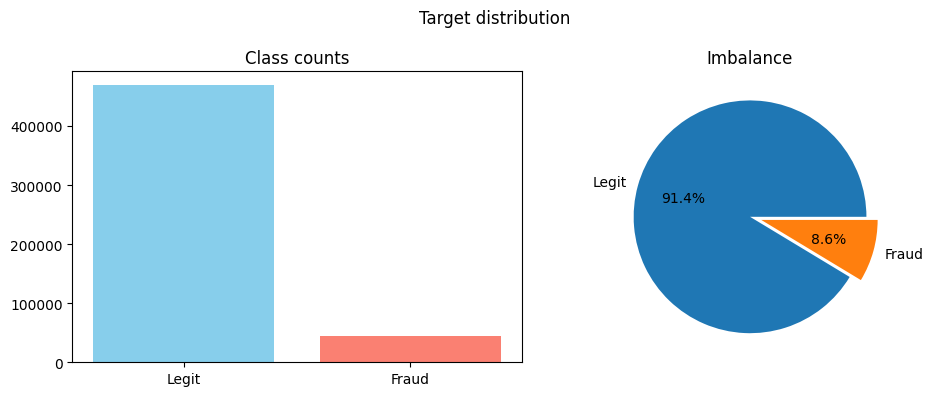


85 numeric features: ['flag', 'length_transaction_hash', 'length_to', 'log_removed', 'block_number', 'gas_used', 'length_from', 'index', 'gas_efficiency', 'value']...

Summary statistics (first 10):
                             count          mean           std      min  \
flag                     513434.0  8.647071e-02  2.810581e-01      0.0   
length_transaction_hash  513434.0  6.600000e+01  0.000000e+00     66.0   
length_to                513434.0  4.148816e+01  4.608164e+00      0.0   
log_removed              513434.0  0.000000e+00  0.000000e+00      0.0   
block_number             513434.0  4.160147e+06  2.101529e+06  46471.0   
gas_used                 513434.0  5.132003e+04  1.155963e+05      0.0   
length_from              513434.0  4.200000e+01  0.000000e+00     42.0   
index                    513434.0  3.961908e+01  4.978944e+01      0.0   
gas_efficiency           513434.0  6.200981e+01  9.021416e+01      0.0   
value                    513434.0  6.874022e+19  2.036892e+

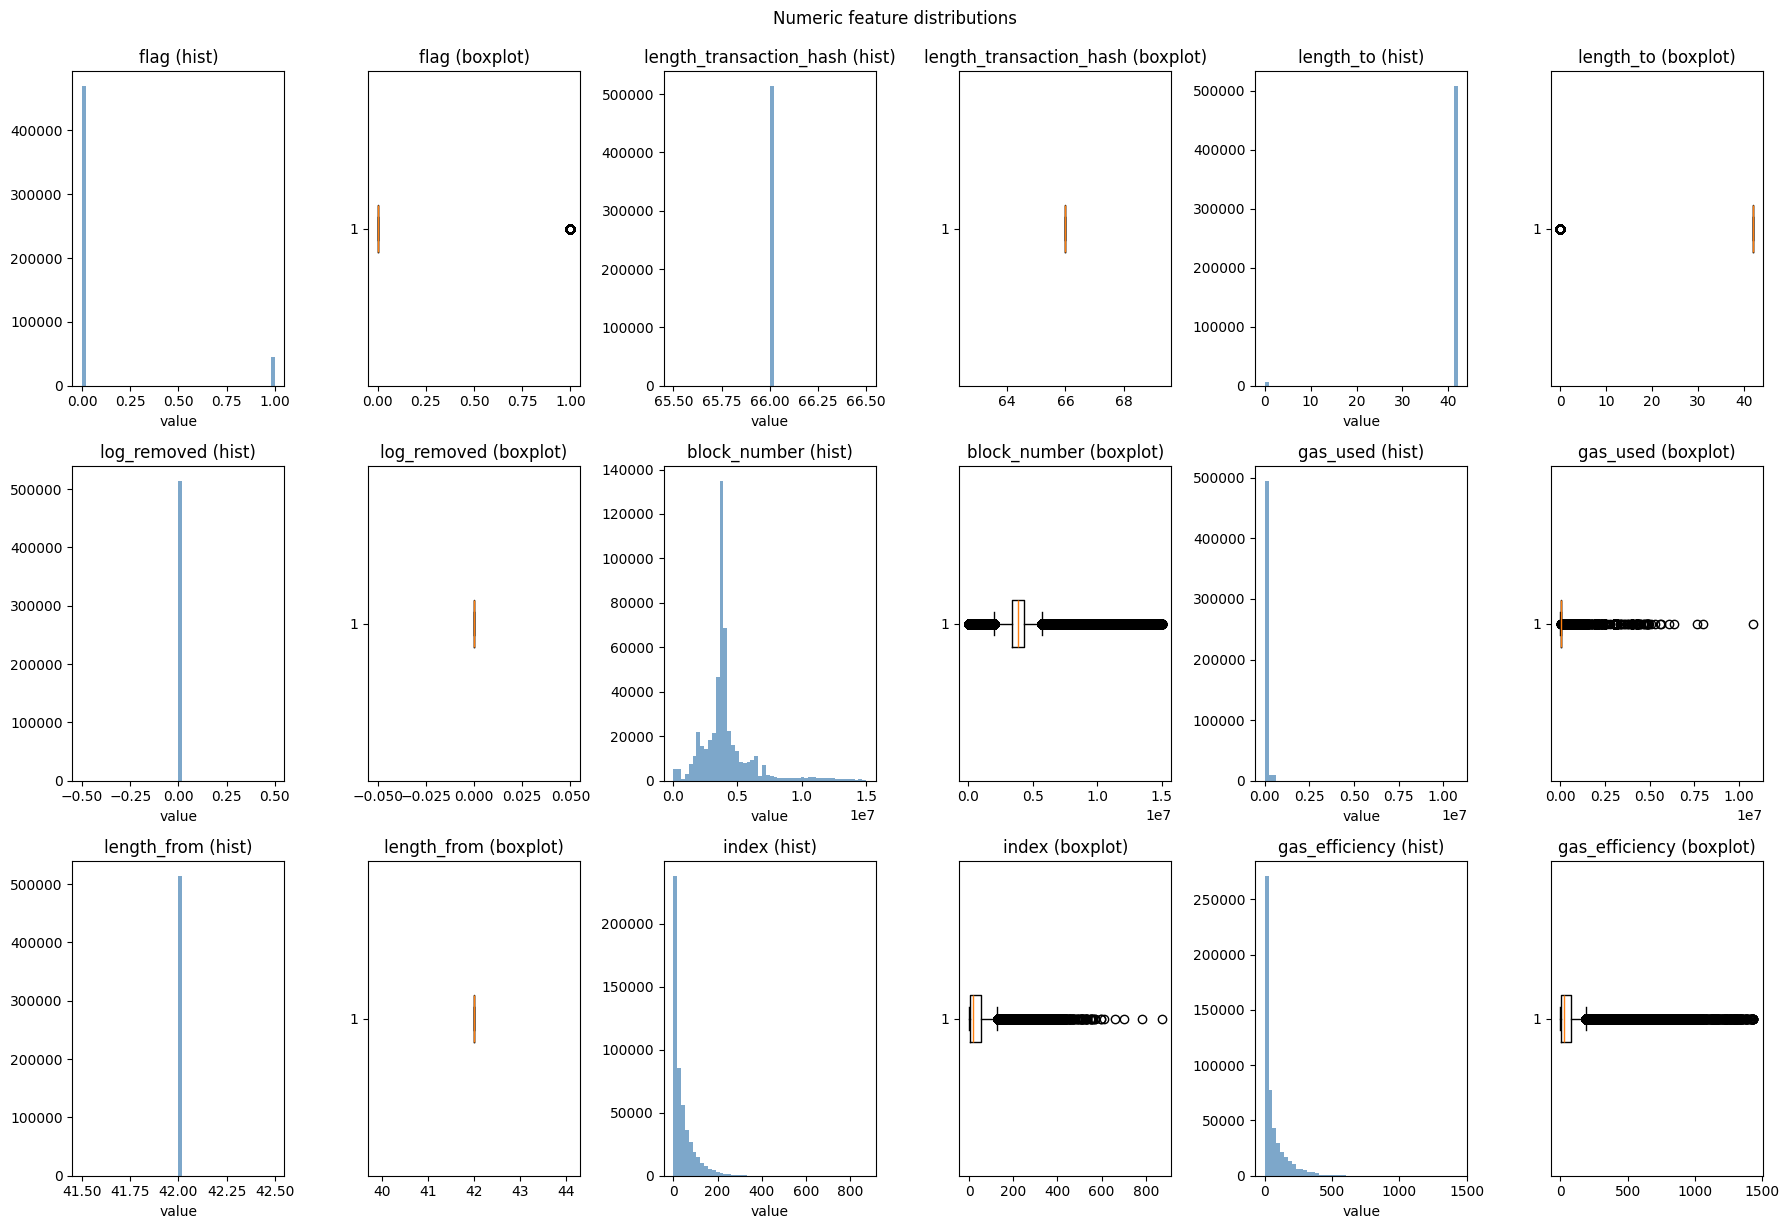


Top 10 features with most outliers (IQR definition):
                                            feature  outliers
53  cumulativeGasUsed.cumulativeGasUsed_minimum_val    123683
16                              effective_gas_price    122313
79                                 nonce.nonce_mode    117827
72                               nonce.nonce_median    113567
35                           gas_used.gas_used_mode    110876
4                                      block_number    109142
24                                 number_of_errors    108758
65                           values.values_variance    107855
70                            nonce.nonce_summation    103817
76                             nonce.nonce_variance     99303

Categorical features: ['hash', 'status', 'message', 'token_transfer_amount', 'Error!']

Value counts for hash:
hash
0xc7752cb98829d08ea39a4d9707c79388a14da0428d66d280a5aac835ca652bf7    1
0x4043b9cc2428c6585947d44d43c44da77b556d026de6ed9c3cc03ce2b7cc6e3e    1
0x5

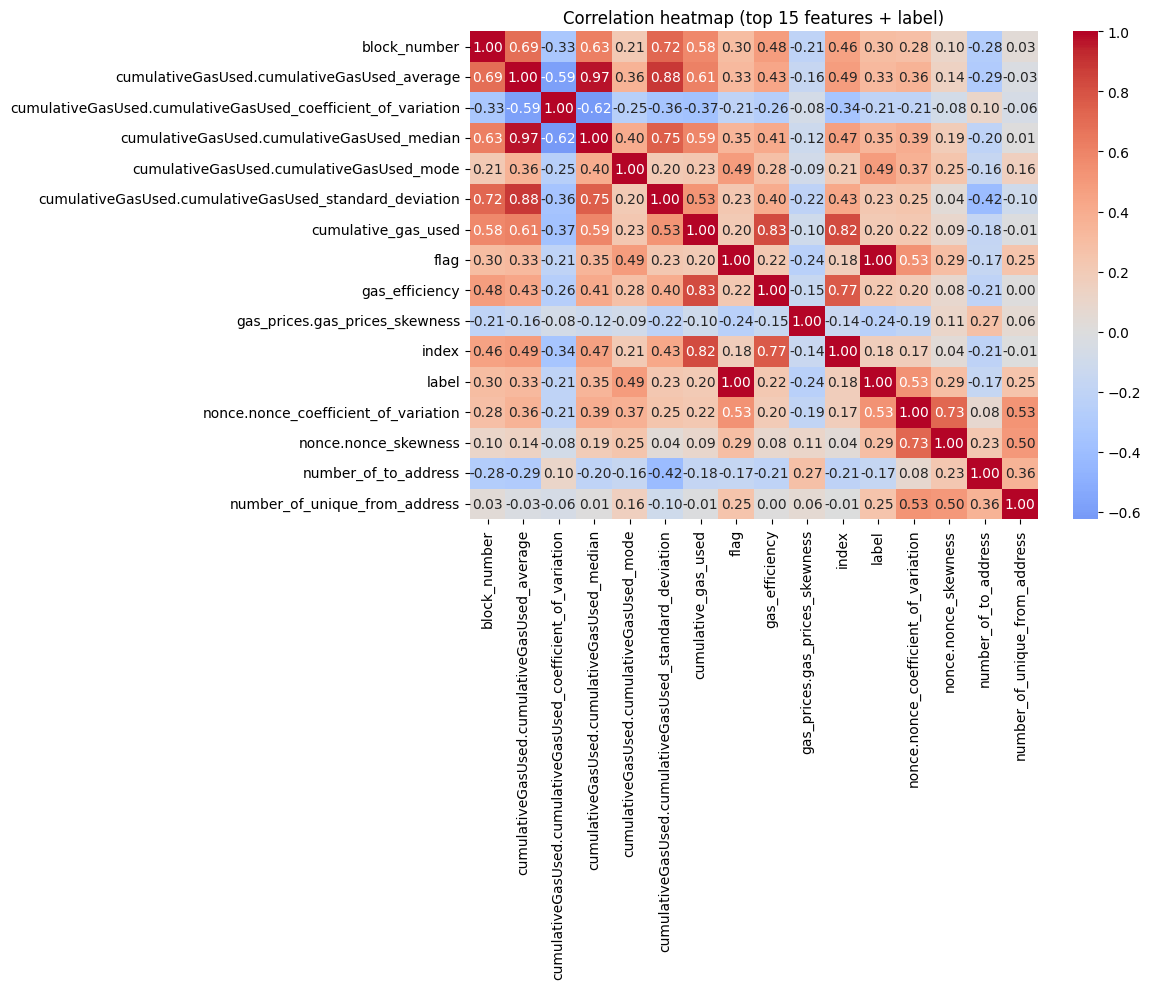


Potential identifier columns present: ['address', 'hash', 'block_number', 'chain_id', 'log_index', 'message', 'status']

--- Checking address leakage risk ---
Total unique addresses: 4051 out of 513434 rows
Addresses that appear more than once: 3400
If any of these appear in both train and test, that's leakage.

--- Temporal analysis (block_number) ---


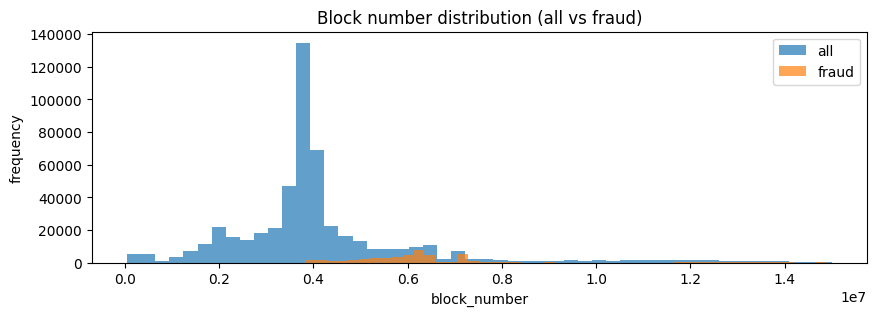

Block number range: 46471 – 14999746
If fraud occurs only in certain blocks, a time‑based split is needed.


In [3]:
# =============================================================================
# COMPREHENSIVE DATA UNDERSTANDING (EDA)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Shape: {df_raw.shape}")
print(f"\nFirst 3 rows:\n{df_raw.head(3)}")
print(f"\nColumn names:\n{list(df_raw.columns)}")
print(f"\nData types:\n{df_raw.dtypes.value_counts()}")

# Missing values
missing = df_raw.isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing values:\n{missing[missing>0]}")
else:
    print("\nNo missing values.")

# Duplicates
dups = df_raw.duplicated().sum()
print(f"\nDuplicate rows: {dups}")

# Target distribution
print("\n" + "="*70)
print("TARGET VARIABLE ('label')")
print("="*70)
target_counts = df_raw['label'].value_counts()
print(target_counts)
print(f"Fraud ratio: {target_counts[1]/len(df_raw):.4f}")

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].bar(['Legit','Fraud'], target_counts, color=['skyblue','salmon'])
axes[0].set_title('Class counts')
axes[1].pie(target_counts, labels=['Legit','Fraud'], autopct='%1.1f%%', explode=(0,0.1))
axes[1].set_title('Imbalance')
plt.suptitle('Target distribution')
plt.tight_layout()
plt.show()

# =============================================================================
# NUMERIC FEATURES ANALYSIS
# =============================================================================
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')
print(f"\n{len(numeric_cols)} numeric features: {numeric_cols[:10]}...")

# Basic stats
stats = df_raw[numeric_cols].describe().T
stats['skew'] = df_raw[numeric_cols].skew()
stats['kurtosis'] = df_raw[numeric_cols].kurtosis()
print("\nSummary statistics (first 10):\n", stats.head(10))

# Zero‑variance features
zero_var = [col for col in numeric_cols if df_raw[col].std() == 0]
print(f"\nZero‑variance features (will be removed): {zero_var if zero_var else 'None'}")

# Distribution plots for first 9 numeric features (histograms + boxplots)
fig, axes = plt.subplots(3, 6, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:9]):
    # Histogram
    axes[i*2].hist(df_raw[col], bins=50, alpha=0.7, color='steelblue')
    axes[i*2].set_title(f'{col} (hist)')
    axes[i*2].set_xlabel('value')
    # Boxplot
    axes[i*2+1].boxplot(df_raw[col], vert=False)
    axes[i*2+1].set_title(f'{col} (boxplot)')
plt.tight_layout()
plt.suptitle('Numeric feature distributions', y=1.02)
plt.show()

# Outlier detection (IQR method)
outlier_summary = {}
for col in numeric_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_summary[col] = outliers
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['feature','outliers']).sort_values('outliers', ascending=False)
print("\nTop 10 features with most outliers (IQR definition):")
print(outlier_df.head(10))

# =============================================================================
# CATEGORICAL FEATURES (if any)
# =============================================================================
categorical_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
if 'address' in categorical_cols:
    categorical_cols.remove('address')  # keep for leakage check later
if categorical_cols:
    print(f"\nCategorical features: {categorical_cols}")
    for col in categorical_cols[:3]:  # limit to 3 for speed
        print(f"\nValue counts for {col}:\n{df_raw[col].value_counts().head(10)}")
else:
    print("\nNo true categorical columns (all numeric or identifiers).")

# =============================================================================
# CORRELATION ANALYSIS
# =============================================================================
# Correlation with target
corr_with_target = df_raw[numeric_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print("\nTop 10 features most correlated with fraud (absolute):")
print(corr_with_target.head(10))
print("\nBottom 10 features (negative correlation):")
print(corr_with_target.tail(10))

# Heatmap of top 15 features by correlation magnitude
top_feats = corr_with_target.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12,10))
sns.heatmap(df_raw[top_feats.union(['label'])].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation heatmap (top 15 features + label)")
plt.tight_layout()
plt.show()

# =============================================================================
# LEAKAGE DETECTION (Identifiers)
# =============================================================================
id_cols = ['address', 'hash', 'block_number', 'chain_id', 'log_index', 'message', 'status', 'Unnamed: 0']
present_ids = [col for col in id_cols if col in df_raw.columns]
print(f"\nPotential identifier columns present: {present_ids}")

if 'address' in df_raw.columns:
    print("\n--- Checking address leakage risk ---")
    addresses = df_raw['address']
    labels = df_raw['label']
    # Simple stratified split
    _, _, y_temp, _ = train_test_split(addresses, labels, test_size=0.2, random_state=42, stratify=labels)
    unique_addrs = addresses.nunique()
    print(f"Total unique addresses: {unique_addrs} out of {len(addresses)} rows")
    addr_counts = addresses.value_counts()
    repeated = addr_counts[addr_counts > 1]
    print(f"Addresses that appear more than once: {len(repeated)}")
    print("If any of these appear in both train and test, that's leakage.")

# =============================================================================
# TEMPORAL / SEQUENTIAL PATTERNS
# =============================================================================
if 'block_number' in df_raw.columns:
    print("\n--- Temporal analysis (block_number) ---")
    plt.figure(figsize=(10,3))
    plt.hist(df_raw['block_number'], bins=50, alpha=0.7, label='all')
    plt.hist(df_raw[df_raw['label']==1]['block_number'], bins=50, alpha=0.7, label='fraud')
    plt.xlabel('block_number')
    plt.ylabel('frequency')
    plt.title('Block number distribution (all vs fraud)')
    plt.legend()
    plt.show()
    print(f"Block number range: {df_raw['block_number'].min()} – {df_raw['block_number'].max()}")
    print("If fraud occurs only in certain blocks, a time‑based split is needed.")

In [4]:
# =============================================================================
# ACTION PLAN – DATA CLEANING & PREPARATION
# Based on comprehensive EDA insights
# =============================================================================

# 1. Drop leaked / identifier / constant columns
cols_to_drop = [
    'flag',                    # perfect correlation with label (leakage)
    'hash',                    # unique per row
    'status',                  # all 'Failed'
    'message',                 # all 'NOTOK'
    'Error!',                  # likely constant
    'address',                 # will use for grouping, but drop after split
    'block_number',            # temporal, but may cause leakage; we keep it?
    'chain_id',                # constant? check
    'log_index',               # identifier
    'length_transaction_hash', # zero variance
    'log_removed',             # zero variance
    'length_from',             # zero variance
    'gas_per_log_event',       # zero variance
    'normalized_token_transfer', # zero variance
    'is_same_address',         # zero variance
    'gas_price_ratio',         # zero variance
    'log_count',               # zero variance
]
# Only drop columns that exist
existing_drop = [c for c in cols_to_drop if c in df_raw.columns]
df_clean = df_raw.drop(columns=existing_drop)
print(f"Dropped {len(existing_drop)} columns: {existing_drop}")

# 2. Handle missing values
missing_counts = df_clean.isnull().sum()
if missing_counts.sum() > 0:
    print(f"Missing values found: {missing_counts[missing_counts>0]}")
    df_clean = df_clean.fillna(0)
    print("Filled missing values with 0.")

# 3. Remove zero-variance features
from sklearn.feature_selection import VarianceThreshold
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')
X_temp = df_clean[numeric_cols].values
selector = VarianceThreshold(threshold=0)
X_temp_var = selector.fit_transform(X_temp)
kept_cols = [numeric_cols[i] for i in range(len(numeric_cols)) if selector.get_support()[i]]
dropped_zero_var = set(numeric_cols) - set(kept_cols)
print(f"Removed zero-variance features: {dropped_zero_var}")
df_clean = df_clean[kept_cols + ['label']]

# 4. Cap outliers (0.5th & 99.5th percentiles + manual cap for gas_used)
df_capped = df_clean.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')
for col in numeric_cols:
    lower = df_clean[col].quantile(0.005)
    upper = df_clean[col].quantile(0.995)
    if col == 'gas_used':
        upper = min(upper, 500000)
    df_capped[col] = df_clean[col].clip(lower, upper)
print("Capped outliers (0.5th-99.5th percentiles, gas_used ≤ 500k).")

df_clean = df_capped.copy()

# 5. Remove highly correlated features (correlation > 0.95) to reduce redundancy
corr_matrix = df_clean[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
if to_drop:
    df_clean = df_clean.drop(columns=to_drop)
    print(f"Dropped highly correlated features (corr > 0.95): {to_drop}")
else:
    print("No highly correlated feature pairs found.")

# 6. Separate features and target
X = df_clean.drop(columns=['label']).values.astype(np.float64)
y = df_clean['label'].values

# 7. Scale with RobustScaler (handles remaining outliers)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 8. Address-based split to prevent leakage
if 'address' in df_raw.columns:
    address_aligned = df_raw.loc[df_clean.index, 'address']
    groups = address_aligned.values
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X_scaled, y, groups=groups))
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    print(f"Train size: {len(X_train)}, test size: {len(X_test)}")
    print(f"Train fraud ratio: {y_train.mean():.4f}, test fraud ratio: {y_test.mean():.4f}")
else:
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 9. Further split for validation (threshold tuning)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
print(f"Training subset: {X_tr.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

print("\nData cleaning complete. Ready for modelling.")

Dropped 17 columns: ['flag', 'hash', 'status', 'message', 'Error!', 'address', 'block_number', 'chain_id', 'log_index', 'length_transaction_hash', 'log_removed', 'length_from', 'gas_per_log_event', 'normalized_token_transfer', 'is_same_address', 'gas_price_ratio', 'log_count']
Missing values found: num_transaction                         29
duration_seconds                        29
number_of_errors                        29
error_rate                              29
gas_used.gas_used_summation             29
                                        ..
nonce.nonce_coefficient_of_variation    29
number_of_from_address                  29
number_of_unique_from_address           29
number_of_to_address                    29
number_of_unique_to_address             29
Length: 63, dtype: int64
Filled missing values with 0.
Removed zero-variance features: set()
Capped outliers (0.5th-99.5th percentiles, gas_used ≤ 500k).
Dropped highly correlated features (corr > 0.95): ['error_rate', 'gas_use

In [5]:
# Save to Drive
drive_path = '/content/drive/MyDrive/defi_hw_comparison/defi_fraud_clean.csv'
df_clean.to_csv(drive_path, index=False)
print(f"Also saved to Drive: {drive_path}")

Also saved to Drive: /content/drive/MyDrive/defi_hw_comparison/defi_fraud_clean.csv


CLEANED DATASET OVERVIEW
Shape: (513434, 61)

Columns (61):
['length_to', 'gas_used', 'index', 'gas_efficiency', 'value', 'total_gas_cost', 'event_activity_flag', 'effective_gas_price', 'cumulative_gas_used', 'length_log', 'num_transaction', 'duration_seconds', 'number_of_errors', 'gas_used.gas_used_summation', 'gas_used.gas_used_average', 'gas_used.gas_used_median', 'gas_used.gas_used_standard_deviation', 'gas_used.gas_used_maximum_val', 'gas_used.gas_used_minimum_val', 'gas_used.gas_used_variance', 'gas_used.gas_used_skewness', 'gas_used.gas_used_mode', 'gas_used.gas_used_coefficient_of_variation', 'gas_prices.gas_prices_summation', 'gas_prices.gas_prices_average', 'gas_prices.gas_prices_median', 'gas_prices.gas_prices_standard_deviation', 'gas_prices.gas_prices_minimum_val', 'gas_prices.gas_prices_skewness', 'gas_prices.gas_prices_mode', 'gas_prices.gas_prices_coefficient_of_variation', 'cumulativeGasUsed.cumulativeGasUsed_summation', 'cumulativeGasUsed.cumulativeGasUsed_average', '

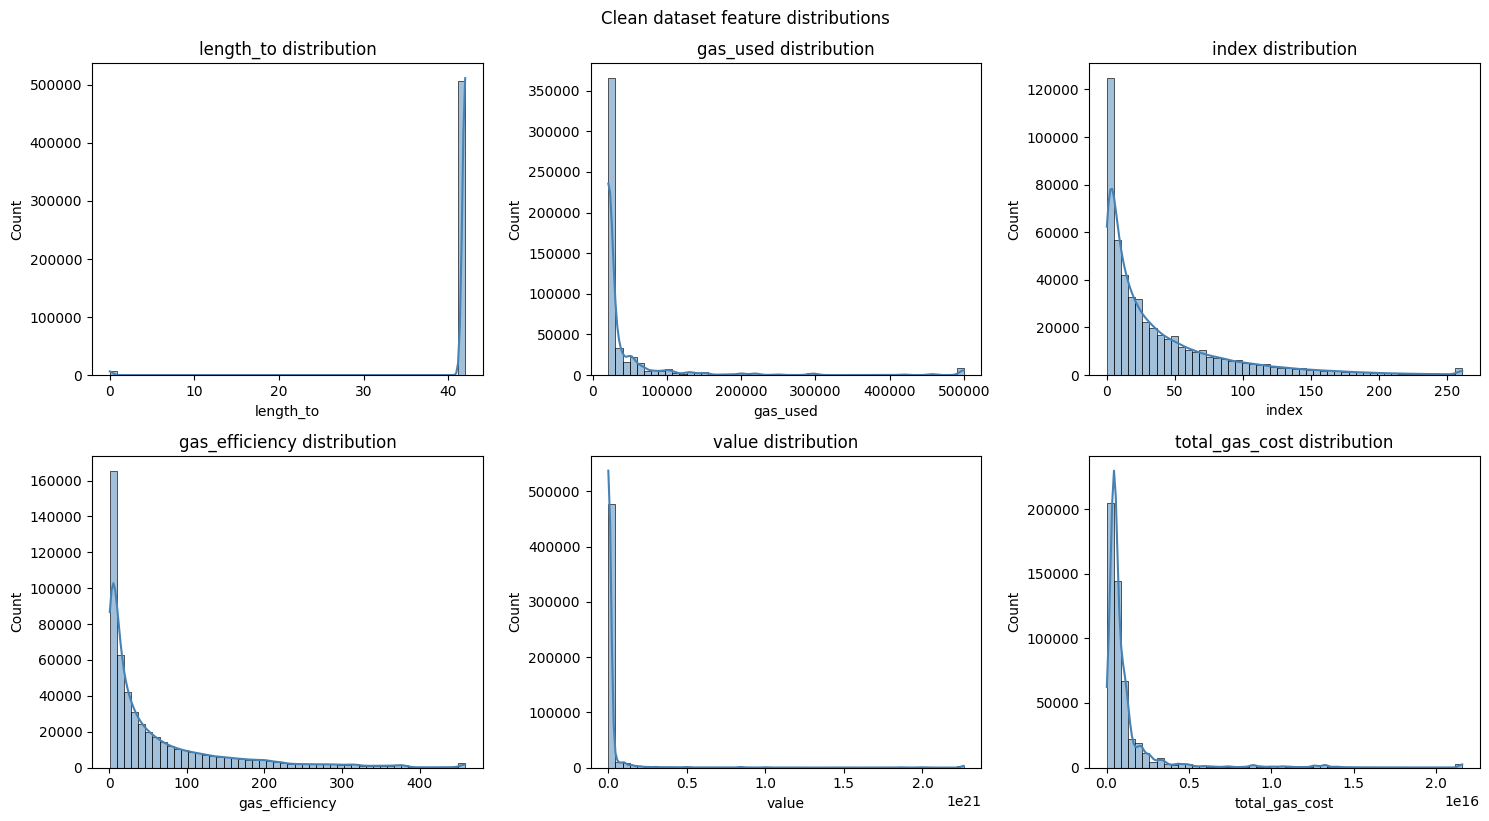

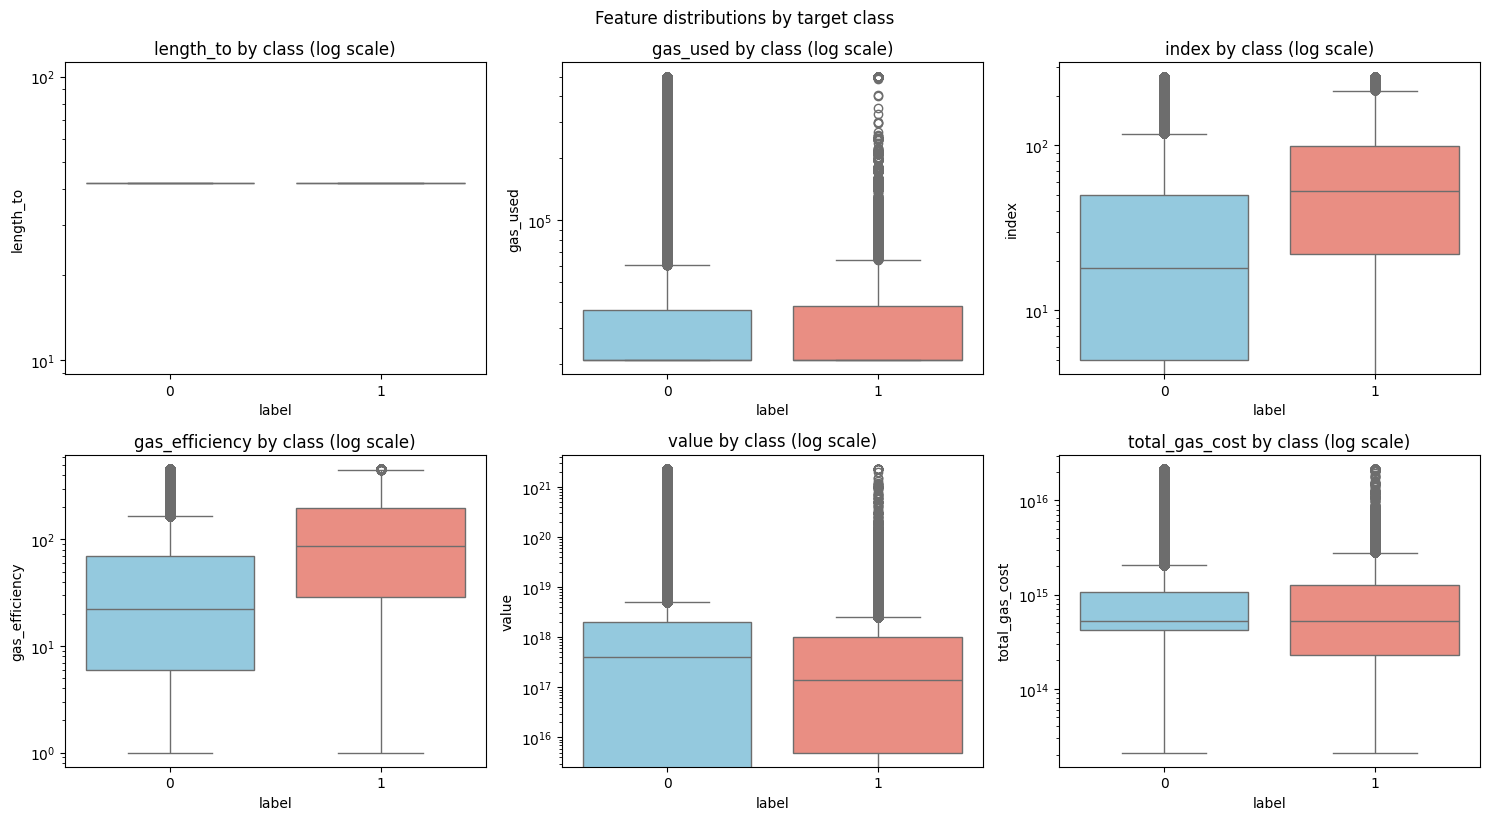


Exploration complete. Data is clean and ready for modelling.


In [6]:
# =============================================================================
# EXPLORE CLEANED DATAFRAME (df_clean)
# =============================================================================
print("="*70)
print("CLEANED DATASET OVERVIEW")
print("="*70)

# Basic info
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):\n{list(df_clean.columns)}")
print(f"\nData types:\n{df_clean.dtypes.value_counts()}")

# Target distribution again
print("\nTarget distribution:")
print(df_clean['label'].value_counts())
print(f"Fraud ratio: {df_clean['label'].mean():.4f}")

# Check for remaining missing values (should be all 0 now)
missing = df_clean.isnull().sum().sum()
print(f"\nTotal missing values after filling: {missing}")

# Check for any constant columns (should be none)
const_cols = [col for col in df_clean.columns if df_clean[col].nunique() == 1 and col != 'label']
print(f"\nConstant columns (if any): {const_cols}")

# Summary statistics of numeric features
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')
print(f"\nNumeric features ({len(numeric_cols)}): {numeric_cols[:10]}...")
print("\nSummary statistics (first 10 features):")
print(df_clean[numeric_cols].describe().T.head(10))

# Check for extreme values after capping
print("\nCheck remaining extreme values (max of each feature):")
max_vals = df_clean[numeric_cols].max().sort_values(ascending=False).head(10)
for col, val in max_vals.items():
    print(f"  {col}: {val:.2e}")

# Correlation with target (top 10)
corr_with_target = df_clean[numeric_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print("\nTop 10 features correlated with fraud (absolute):")
print(corr_with_target.head(10))
print("\nBottom 10 features (negative correlation):")
print(corr_with_target.tail(10))

# Visualisations (quick)
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of top 6 numeric features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:6]):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], bins=50, color='steelblue')
    axes[i].set_title(f'{col} distribution')
plt.tight_layout()
plt.suptitle('Clean dataset feature distributions', y=1.02)
plt.show()

# Boxplots of top 6 features by class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:6]):
    sns.boxplot(x='label', y=col, data=df_clean, ax=axes[i], palette=['skyblue','salmon'])
    axes[i].set_yscale('log')
    axes[i].set_title(f'{col} by class (log scale)')
plt.tight_layout()
plt.suptitle('Feature distributions by target class', y=1.02)
plt.show()

print("\nExploration complete. Data is clean and ready for modelling.")

In [7]:
# Quick final check
print("Training set shape:", X_tr.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print("Any NaN in training features?", np.isnan(X_tr).any())
print("Any inf in training features?", np.isinf(X_tr).any())
print("Feature ranges (first 5):", X_tr[:, :5].max(axis=0))

Training set shape: (323432, 60)
Validation set shape: (80859, 60)
Test set shape: (109143, 60)
Any NaN in training features? False
Any inf in training features? False
Feature ranges (first 5): [   0.           30.10306687    4.91836735    5.88631202 1131.27872753]


In [8]:
# =============================================================================
# FINAL MODELLING (RF, XGBoost, LightGBM)
# =============================================================================
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, average_precision_score,
                             precision_recall_curve, PrecisionRecallDisplay)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold

models = {}

# ============================= RANDOM FOREST =============================
print("\n--- Random Forest ---")
ram_before = psutil.virtual_memory().used / 1e9
disk_before = psutil.disk_usage("/").used / 1e9
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_tr, y_tr)
train_time = time.perf_counter() - t0
ram_after = psutil.virtual_memory().used / 1e9
disk_after = psutil.disk_usage("/").used / 1e9

# threshold tuning on validation
y_prob_val_rf = rf.predict_proba(X_val)[:, 1]
prec_rf, rec_rf, thresh_rf = precision_recall_curve(y_val, y_prob_val_rf)
f1_scores_rf = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf + 1e-9)
best_thresh_rf = thresh_rf[np.argmax(f1_scores_rf)]
y_pred_rf = (rf.predict_proba(X_test)[:, 1] > best_thresh_rf).astype(int)
y_prob_test_rf = rf.predict_proba(X_test)[:, 1]
metrics_rf = record_metrics("Random Forest", train_time, ram_before, ram_after, disk_before, disk_after, y_test, y_pred_rf, y_prob_test_rf)
print(f"RF done. F1={metrics_rf['F1 Score']:.4f}, PR-AUC={metrics_rf['PR-AUC']:.4f}")
models["Random Forest"] = {
    "model": rf,
    "y_pred": y_pred_rf,
    "y_prob": y_prob_test_rf,
    "prec": prec_rf,
    "rec": rec_rf,
    "thresh": best_thresh_rf
}

# ============================= XGBOOST =============================
print("\n--- XGBoost ---")
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()
scale_weights = [neg/pos, 2*neg/pos, 5*neg/pos, 10]
best_weight, best_cv = None, 0
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
device = "cuda" if HARDWARE == "GPU" else "cpu"
xgb_base = {"objective":"binary:logistic","tree_method":"hist","device":device,"learning_rate":0.1,
            "max_depth":6,"subsample":0.8,"colsample_bytree":0.8,"seed":42}
for w in scale_weights:
    params = xgb_base.copy()
    params["scale_pos_weight"] = w
    cv_scores = []
    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        Xtr, Xv = X_tr[tr_idx], X_tr[val_idx]
        ytr, yv = y_tr[tr_idx], y_tr[val_idx]
        m = xgb.train(params, xgb.DMatrix(Xtr, label=ytr), num_boost_round=100, verbose_eval=False)
        cv_scores.append(average_precision_score(yv, m.predict(xgb.DMatrix(Xv))))
    mean_pr = np.mean(cv_scores)
    if mean_pr > best_cv:
        best_cv, best_weight = mean_pr, w
xgb_params = xgb_base.copy()
xgb_params["scale_pos_weight"] = best_weight

ram_before = psutil.virtual_memory().used / 1e9
disk_before = psutil.disk_usage("/").used / 1e9
t0 = time.perf_counter()
xgb_model = xgb.train(xgb_params, xgb.DMatrix(X_tr, label=y_tr), num_boost_round=100, verbose_eval=False)
train_time = time.perf_counter() - t0
ram_after = psutil.virtual_memory().used / 1e9
disk_after = psutil.disk_usage("/").used / 1e9

y_prob_val_xgb = xgb_model.predict(xgb.DMatrix(X_val))
prec_xgb, rec_xgb, thresh_xgb = precision_recall_curve(y_val, y_prob_val_xgb)
f1_scores_xgb = 2 * (prec_xgb * rec_xgb) / (prec_xgb + rec_xgb + 1e-9)
best_thresh_xgb = thresh_xgb[np.argmax(f1_scores_xgb)]
y_prob_test_xgb = xgb_model.predict(xgb.DMatrix(X_test))
y_pred_xgb = (y_prob_test_xgb > best_thresh_xgb).astype(int)
metrics_xgb = record_metrics("XGBoost", train_time, ram_before, ram_after, disk_before, disk_after, y_test, y_pred_xgb, y_prob_test_xgb)
print(f"XGB done. F1={metrics_xgb['F1 Score']:.4f}, PR-AUC={metrics_xgb['PR-AUC']:.4f}")
models["XGBoost"] = {
    "model": xgb_model,
    "y_pred": y_pred_xgb,
    "y_prob": y_prob_test_xgb,
    "prec": prec_xgb,
    "rec": rec_xgb,
    "thresh": best_thresh_xgb
}

# ============================= LIGHTGBM (baseline) =============================
print("\n--- LightGBM (baseline) ---")
best_lgb_weight, best_lgb_cv = None, 0
lgb_base = {"objective":"binary","metric":"aucpr","boosting":"gbdt","num_leaves":31,
            "learning_rate":0.1,"feature_fraction":0.8,"bagging_fraction":0.8,"seed":42}
for w in scale_weights:
    params = lgb_base.copy()
    params["scale_pos_weight"] = w
    cv_scores = []
    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        Xtr, Xv = X_tr[tr_idx], X_tr[val_idx]
        ytr, yv = y_tr[tr_idx], y_tr[val_idx]
        lgb_train = lgb.Dataset(Xtr, label=ytr)
        lgb_val = lgb.Dataset(Xv, label=yv, reference=lgb_train)
        m = lgb.train(params, lgb_train, num_boost_round=100, valid_sets=[lgb_val], callbacks=[lgb.log_evaluation(0)])
        cv_scores.append(average_precision_score(yv, m.predict(Xv)))
    mean_pr = np.mean(cv_scores)
    if mean_pr > best_lgb_cv:
        best_lgb_cv, best_lgb_weight = mean_pr, w
lgb_params = lgb_base.copy()
lgb_params["scale_pos_weight"] = best_lgb_weight

ram_before = psutil.virtual_memory().used / 1e9
disk_before = psutil.disk_usage("/").used / 1e9
t0 = time.perf_counter()
lgb_train = lgb.Dataset(X_tr, label=y_tr)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=100, valid_sets=[lgb_val], callbacks=[lgb.log_evaluation(0)])
train_time = time.perf_counter() - t0
ram_after = psutil.virtual_memory().used / 1e9
disk_after = psutil.disk_usage("/").used / 1e9

y_prob_val_lgb = lgb_model.predict(X_val)
prec_lgb, rec_lgb, thresh_lgb = precision_recall_curve(y_val, y_prob_val_lgb)
f1_scores_lgb = 2 * (prec_lgb * rec_lgb) / (prec_lgb + rec_lgb + 1e-9)
best_thresh_lgb = thresh_lgb[np.argmax(f1_scores_lgb)]
y_prob_test_lgb = lgb_model.predict(X_test)
y_pred_lgb = (y_prob_test_lgb > best_thresh_lgb).astype(int)
metrics_lgb = record_metrics("LightGBM (baseline)", train_time, ram_before, ram_after, disk_before, disk_after, y_test, y_pred_lgb, y_prob_test_lgb)
print(f"LGB baseline done. F1={metrics_lgb['F1 Score']:.4f}, PR-AUC={metrics_lgb['PR-AUC']:.4f}")
models["LightGBM (baseline)"] = {
    "model": lgb_model,
    "y_pred": y_pred_lgb,
    "y_prob": y_prob_test_lgb,
    "prec": prec_lgb,
    "rec": rec_lgb,
    "thresh": best_thresh_lgb
}


--- Random Forest ---
RF done. F1=0.3641, PR-AUC=0.8751

--- XGBoost ---
XGB done. F1=0.5882, PR-AUC=0.9542

--- LightGBM (baseline) ---
[LightGBM] [Info] Number of positive: 18272, number of negative: 197349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12598
[LightGBM] [Info] Number of data points in the train set: 215621, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.084741 -> initscore=-2.379604
[LightGBM] [Info] Start training from score -2.379604
[LightGBM] [Info] Number of positive: 18272, number of negative: 197349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.080843 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12574
[LightGBM] [Info] Number of data points in the train set: 215621, number of used features: 60
[L


FINAL METRICS ON TEST SET (optimised thresholds)
Random Forest | Accuracy: 0.9274 | F1: 0.3641 | PR-AUC: 0.8751 | Fraud Recall: 0.2237
XGBoost      | Accuracy: 0.9455 | F1: 0.5882 | PR-AUC: 0.9542 | Fraud Recall: 0.4188
LightGBM (baseline) | Accuracy: 0.9485 | F1: 0.6224 | PR-AUC: 0.9578 | Fraud Recall: 0.4566

🏆 Best model: LightGBM (baseline) (PR-AUC = 0.9578)


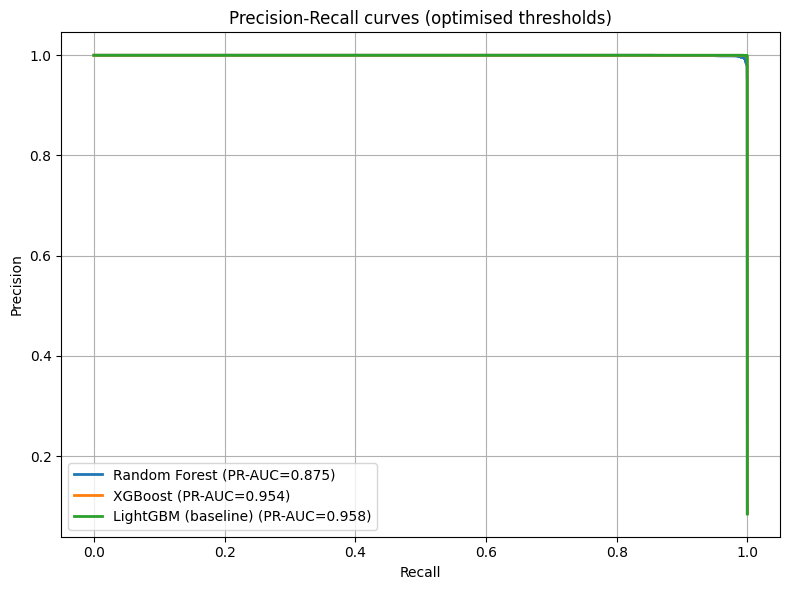

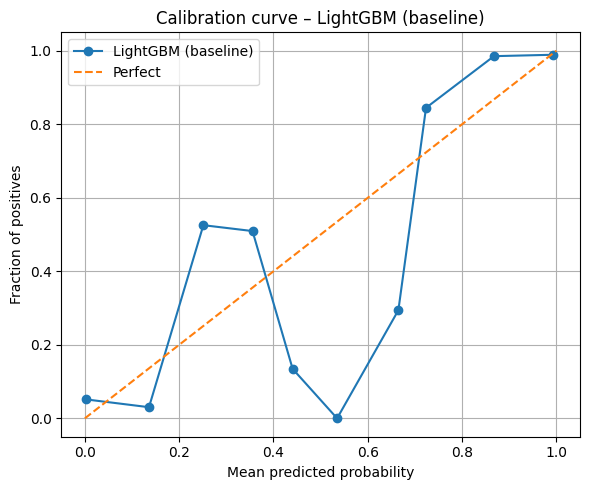


Modelling complete. All plots saved.


In [9]:
# ============================= RESULTS & VISUALISATIONS =============================
print("\n" + "="*70)
print("FINAL METRICS ON TEST SET (optimised thresholds)")
print("="*70)
for name, m in models.items():
    acc = accuracy_score(y_test, m['y_pred'])
    f1 = f1_score(y_test, m['y_pred'])
    pr_auc = average_precision_score(y_test, m['y_prob'])
    rec_fraud = recall_score(y_test, m['y_pred'])
    print(f"{name:12} | Accuracy: {acc:.4f} | F1: {f1:.4f} | PR-AUC: {pr_auc:.4f} | Fraud Recall: {rec_fraud:.4f}")

# Best model (by PR-AUC)
best_name = max(models, key=lambda name: average_precision_score(y_test, models[name]['y_prob']))
best = models[best_name]
print(f"\n🏆 Best model: {best_name} (PR-AUC = {average_precision_score(y_test, best['y_prob']):.4f})")

# 1. PR curves
plt.figure(figsize=(8,6))
for name, m in models.items():
    plt.plot(m['rec'], m['prec'], lw=2, label=f"{name} (PR-AUC={average_precision_score(y_test, m['y_prob']):.3f})")
plt.xlabel('Recall'), plt.ylabel('Precision')
plt.title('Precision‑Recall curves (optimised thresholds)')
plt.legend(), plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curves_clean.png")
plt.show()

# 2. Calibration curve (best model)
prob_true, prob_pred = calibration_curve(y_test, best['y_prob'], n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label=best_name)
plt.plot([0,1], [0,1], '--', label='Perfect')
plt.xlabel('Mean predicted probability'), plt.ylabel('Fraction of positives')
plt.title(f'Calibration curve – {best_name}')
plt.legend(), plt.grid(True)
plt.tight_layout()
plt.savefig("calibration_best_clean.png")
plt.show()

print("\nModelling complete. All plots saved.")

In [10]:
# =============================================================================
# HYPERPARAMETER OPTIMISATION FOR LIGHTGBM (Optuna)
# =============================================================================
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])

import optuna
import lightgbm as lgb
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'aucpr',
        'boosting': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 20.0),
        'seed': 42,
        'verbose': -1,
        'n_jobs': -1
    }

    lgb_train = lgb.Dataset(X_tr, label=y_tr)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)


    model = lgb.train(params, lgb_train, num_boost_round=100,
                      valid_sets=[lgb_val], callbacks=[lgb.log_evaluation(0)])

    # Predict on validation set
    y_prob_val = model.predict(X_val)

    # Optimise threshold on validation (maximise F1)
    prec, rec, thresh = precision_recall_curve(y_val, y_prob_val)
    f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
    best_thresh = thresh[np.argmax(f1_scores)]
    y_pred_val = (y_prob_val > best_thresh).astype(int)
    f1 = f1_score(y_val, y_pred_val)

    return f1

# Run optimisation (20 trials)
study = optuna.create_study(direction='maximize', study_name='lgbm_fraud')
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Best parameters
best_params = study.best_params
print("\n✅ Best hyperparameters found:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Add fixed parameters
best_params.update({
    'objective': 'binary',
    'metric': 'aucpr',
    'boosting': 'gbdt',
    'seed': 42,
    'verbose': -1,
    'n_jobs': -1
})

# =============================================================================
# Train final model on combined training + validation sets (with timing)
# =============================================================================
print("\nTraining optimised LightGBM on full training+validation set...")
ram_before_opt = psutil.virtual_memory().used / 1e9
disk_before_opt = psutil.disk_usage("/").used / 1e9
t0 = time.perf_counter()

X_train_full = np.vstack([X_tr, X_val])
y_train_full = np.hstack([y_tr, y_val])
lgb_full = lgb.Dataset(X_train_full, label=y_train_full)
final_model = lgb.train(best_params, lgb_full, num_boost_round=300, callbacks=[lgb.log_evaluation(100)])

train_time_opt = time.perf_counter() - t0
ram_after_opt = psutil.virtual_memory().used / 1e9
disk_after_opt = psutil.disk_usage("/").used / 1e9

# Evaluate on test set with threshold tuning
y_prob_test_opt = final_model.predict(X_test)
prec_opt, rec_opt, thresh_opt = precision_recall_curve(y_test, y_prob_test_opt)
f1_opt = 2 * (prec_opt * rec_opt) / (prec_opt + rec_opt + 1e-9)
best_thresh_opt = thresh_opt[np.argmax(f1_opt)]
y_pred_test_opt = (y_prob_test_opt > best_thresh_opt).astype(int)

metrics_opt_lgb = record_metrics("LightGBM (optimised)", train_time_opt, ram_before_opt, ram_after_opt, disk_before_opt, disk_after_opt, y_test, y_pred_test_opt, y_prob_test_opt)
print(f"Optimised LGB done. F1={metrics_opt_lgb['F1 Score']:.4f}, PR-AUC={metrics_opt_lgb['PR-AUC']:.4f}")
print(f"Optimal threshold: {best_thresh_opt:.4f}")

# Compare with baseline (use actual baseline metrics from metrics_lgb)
print("\n--- Improvement over baseline ---")
baseline_f1 = metrics_lgb['F1 Score']
baseline_recall = metrics_lgb['Fraud Recall']
baseline_pr_auc = metrics_lgb['PR-AUC']
print(f"Baseline F1: {baseline_f1:.4f} → Optimised F1: {metrics_opt_lgb['F1 Score']:.4f} (Δ = {metrics_opt_lgb['F1 Score'] - baseline_f1:+.4f})")
print(f"Baseline Recall: {baseline_recall:.4f} → Optimised Recall: {metrics_opt_lgb['Fraud Recall']:.4f} (Δ = {metrics_opt_lgb['Fraud Recall'] - baseline_recall:+.4f})")
print(f"Baseline PR-AUC: {baseline_pr_auc:.4f} → Optimised PR-AUC: {metrics_opt_lgb['PR-AUC']:.4f} (Δ = {metrics_opt_lgb['PR-AUC'] - baseline_pr_auc:+.4f})")


[I 2026-04-28 20:43:07,765] A new study created in memory with name: lgbm_fraud


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-28 20:43:12,989] Trial 0 finished with value: 0.9994163991829589 and parameters: {'num_leaves': 124, 'learning_rate': 0.08282269153629147, 'feature_fraction': 0.6641723904369279, 'bagging_fraction': 0.7132803422897128, 'bagging_freq': 3, 'lambda_l1': 0.00034031555907721415, 'lambda_l2': 1.898001763367782e-08, 'min_child_samples': 77, 'scale_pos_weight': 15.160734899281984}. Best is trial 0 with value: 0.9994163991829589.
[I 2026-04-28 20:43:18,378] Trial 1 finished with value: 0.9967911318553092 and parameters: {'num_leaves': 139, 'learning_rate': 0.010272220835153908, 'feature_fraction': 0.8389941550570701, 'bagging_fraction': 0.6512066763887361, 'bagging_freq': 4, 'lambda_l1': 7.163649216011117e-07, 'lambda_l2': 0.00016846665707502819, 'min_child_samples': 68, 'scale_pos_weight': 15.238697955023056}. Best is trial 0 with value: 0.9994163991829589.
[I 2026-04-28 20:43:22,872] Trial 2 finished with value: 0.9976652560922223 and parameters: {'num_leaves': 112, 'learning_rate'

In [11]:
# =============================================================================
# Collect and save hardware metrics for this run
# =============================================================================
all_metrics = [metrics_rf, metrics_xgb, metrics_lgb, metrics_opt_lgb]
df_run = pd.DataFrame(all_metrics)

SAVE_DIR = "/content/drive/MyDrive/defi_hw_comparison/"
os.makedirs(SAVE_DIR, exist_ok=True)
CSV_PATH = os.path.join(SAVE_DIR, "hardware_comparison_metrics.csv")

if os.path.exists(CSV_PATH):
    df_existing = pd.read_csv(CSV_PATH)
    df_combined = pd.concat([df_existing, df_run], ignore_index=True)
    df_combined = df_combined.drop_duplicates(subset=["Hardware", "Model"], keep="last")
else:
    df_combined = df_run

df_combined.to_csv(CSV_PATH, index=False)
print(f"Metrics saved to {CSV_PATH}")

Metrics saved to /content/drive/MyDrive/defi_hw_comparison/hardware_comparison_metrics.csv


In [12]:
from sklearn.metrics import precision_score, confusion_matrix
# Use optimised model predictions
y_pred_test_opt = (y_prob_test_opt > best_thresh_opt).astype(int)
precision = precision_score(y_test, y_pred_test_opt)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_opt).ravel()
print(f"Optimised model – Precision: {precision:.4f}")
print(f"False Positives: {fp} (out of {tn+fp} legit)")
print(f"False Negatives: {fn} (out of {fn+tp} fraud)")

Optimised model – Precision: 0.9569
False Positives: 445 (out of 99006 legit)
False Negatives: 253 (out of 10137 fraud)


Accuracy: 0.9936, Precision: 0.9569, Recall: 0.9750, F1: 0.9659
PR-AUC: 0.9671, ROC-AUC: 0.9953
False Positive Rate: 0.0045, False Negative Rate: 0.0250


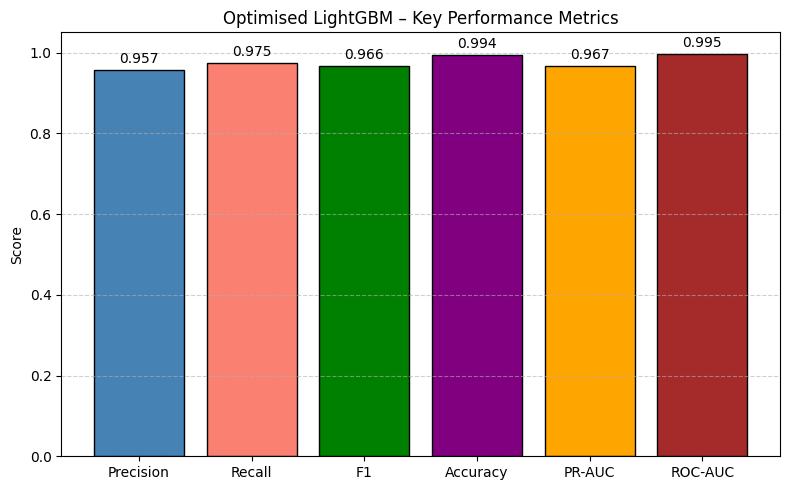

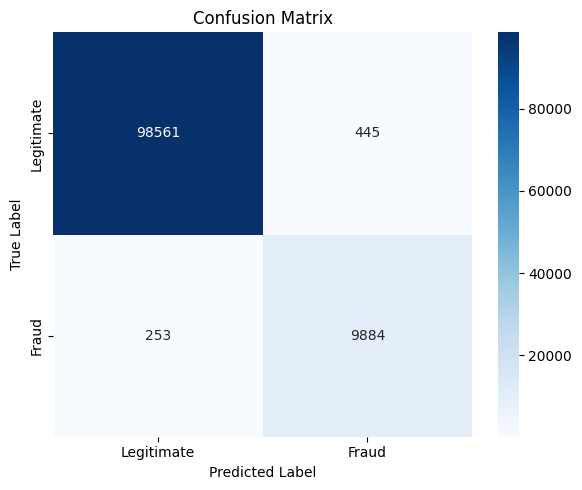

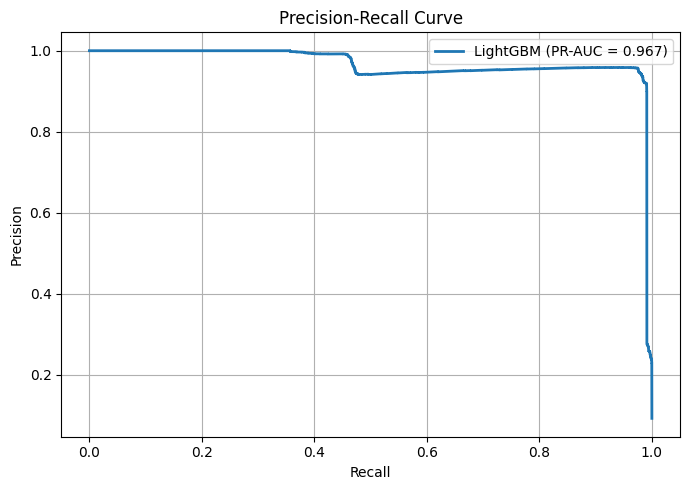

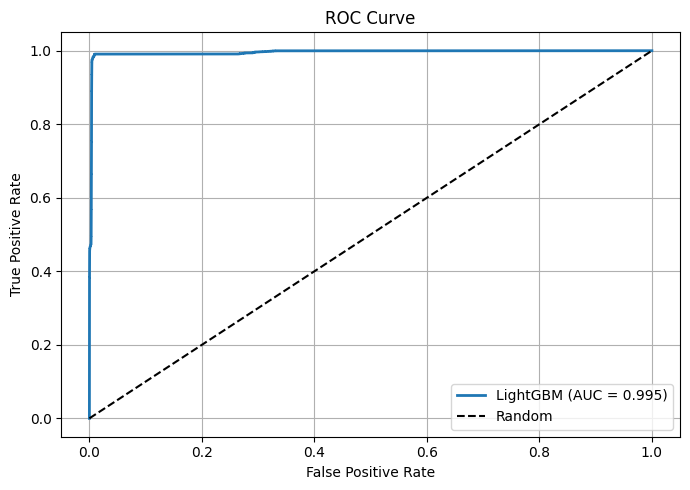

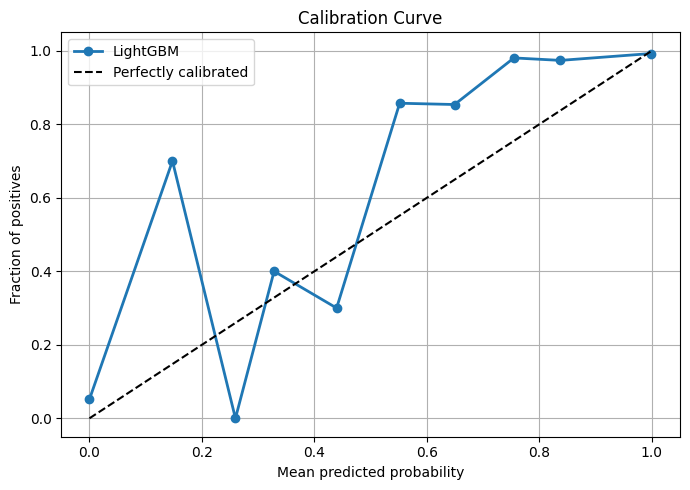

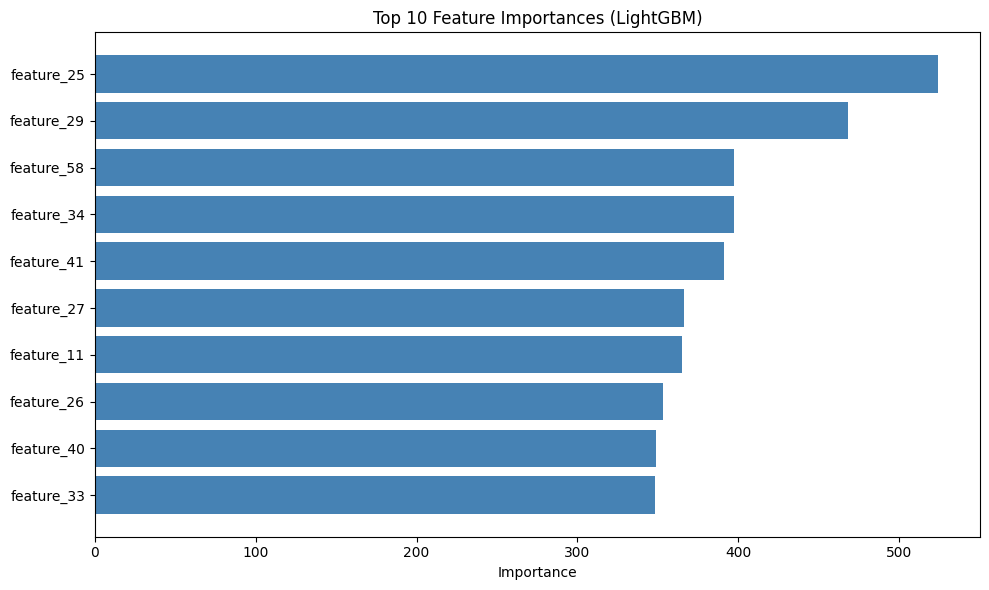


✅ All six visualizations saved.


In [13]:
# =============================================================================
# VISUALIZE KEY METRICS FOR OPTIMISED LIGHTGBM
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score
)
from sklearn.calibration import calibration_curve

# Use optimised model predictions (variables already defined)
y_prob_test_opt = final_model.predict(X_test)
y_pred_test_opt = (y_prob_test_opt > best_thresh_opt).astype(int)

acc = accuracy_score(y_test, y_pred_test_opt)
prec = precision_score(y_test, y_pred_test_opt)
rec = recall_score(y_test, y_pred_test_opt)
f1 = f1_score(y_test, y_pred_test_opt)
pr_auc = average_precision_score(y_test, y_prob_test_opt)
roc_auc = roc_auc_score(y_test, y_prob_test_opt)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_opt).ravel()

fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
print(f"PR-AUC: {pr_auc:.4f}, ROC-AUC: {roc_auc:.4f}")
print(f"False Positive Rate: {fpr:.4f}, False Negative Rate: {fnr:.4f}")

# 1. Bar chart of key metrics
metrics = ['Precision', 'Recall', 'F1', 'Accuracy', 'PR-AUC', 'ROC-AUC']
values = [prec, rec, f1, acc, pr_auc, roc_auc]
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['steelblue','salmon','green','purple','orange','brown'], edgecolor='black')
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.ylim(0, 1.05)
plt.title('Optimised LightGBM – Key Performance Metrics')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150)
plt.show()

# 2. Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_test_opt)   # FIXED: use y_pred_test_opt
labels = ['Legitimate', 'Fraud']
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png', dpi=150)
plt.show()

# 3. Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test_opt)   # FIXED: use y_prob_test_opt
plt.figure(figsize=(7,5))
plt.plot(rec_curve, prec_curve, lw=2, label=f'LightGBM (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

# 4. ROC curve
fpr_roc, tpr_roc, _ = roc_curve(y_test, y_prob_test_opt)   # FIXED: use y_prob_test_opt
plt.figure(figsize=(7,5))
plt.plot(fpr_roc, tpr_roc, lw=2, label=f'LightGBM (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# 5. Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_test_opt, n_bins=10)   # FIXED: use y_prob_test_opt
plt.figure(figsize=(7,5))
plt.plot(prob_pred, prob_true, marker='o', lw=2, label='LightGBM')
plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()

# 6. Feature importance (top 10)
importances = final_model.feature_importance()
feature_names = [f'feature_{i}' for i in range(X_train_full.shape[1])]
top_idx = np.argsort(importances)[-10:]
top_importance = importances[top_idx]
top_features = [feature_names[i] for i in top_idx]
plt.figure(figsize=(10,6))
plt.barh(range(10), top_importance, color='steelblue')
plt.yticks(range(10), top_features)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (LightGBM)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n✅ All six visualizations saved.")

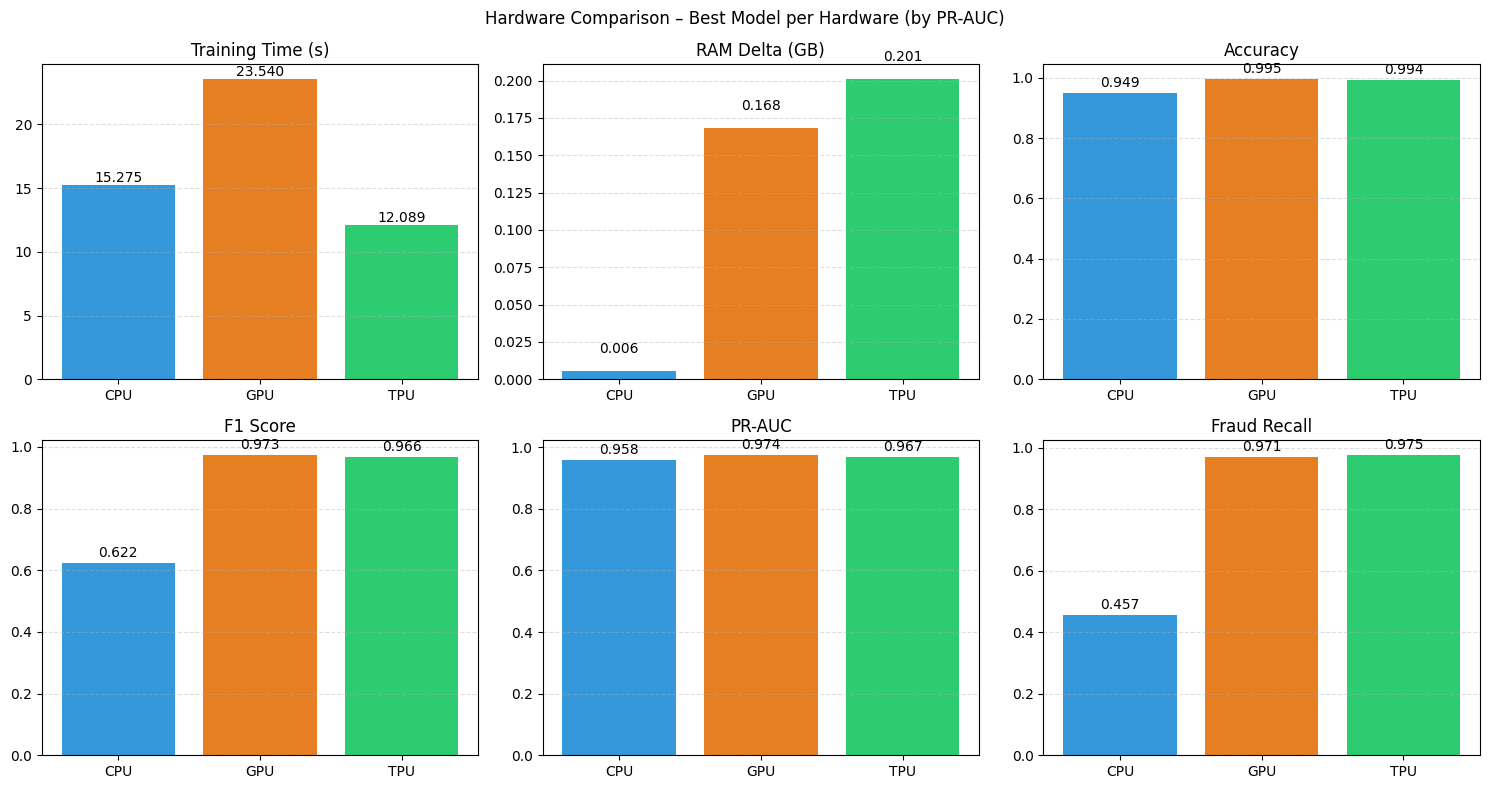

Comparison chart saved to /content/drive/MyDrive/defi_hw_comparison/hardware_comparison.png

  SPEEDUP vs CPU (Training Time)
Hardware  Time (s)  Speedup vs CPU
     CPU   15.2747            1.00
     GPU   23.5402            0.65
     TPU   12.0895            1.26

Speedup table saved to /content/drive/MyDrive/defi_hw_comparison/speedup_table.csv


In [14]:
# =============================================================================
# HARDWARE COMPARISON (CPU vs GPU vs TPU) – GENERATE CHARTS
# =============================================================================
def generate_hardware_comparison(csv_path):
    if not os.path.exists(csv_path):
        print(f"No comparison file found at {csv_path}. Run on CPU, GPU, and TPU first.")
        return

    df = pd.read_csv(csv_path)
    available_hw = set(df["Hardware"].unique())
    required = {"CPU", "GPU", "TPU"}
    if not required.issubset(available_hw):
        print(f"Missing hardware: {required - available_hw}. Run the missing sessions.")
        return

    # Select best model per hardware (by PR-AUC)
    best_models = df.loc[df.groupby("Hardware")["PR-AUC"].idxmax()]

    metrics = ["Training Time (s)", "RAM Delta (GB)", "Accuracy", "F1 Score", "PR-AUC", "Fraud Recall"]
    hw_order = ["CPU", "GPU", "TPU"]
    colors = {"CPU": "#3498db", "GPU": "#e67e22", "TPU": "#2ecc71"}

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax, metric in zip(axes, metrics):
        vals = []
        for hw in hw_order:
            val = best_models.loc[best_models["Hardware"] == hw, metric].values
            vals.append(val[0] if len(val) > 0 else 0)
        bars = ax.bar(hw_order, vals, color=[colors[hw] for hw in hw_order])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + (0.01 if v > 0 else 0.1), f"{v:.3f}", ha="center", va="bottom")
        ax.set_title(metric)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.suptitle("Hardware Comparison – Best Model per Hardware (by PR-AUC)")
    plt.tight_layout()
    out_path = os.path.join(SAVE_DIR, "hardware_comparison.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Comparison chart saved to {out_path}")

    # Speedup table (vs CPU)
    cpu_time = best_models.loc[best_models["Hardware"] == "CPU", "Training Time (s)"].values[0]
    print("\n" + "="*55)
    print("  SPEEDUP vs CPU (Training Time)")
    print("="*55)
    speed_rows = []
    for hw in hw_order:
        t = best_models.loc[best_models["Hardware"] == hw, "Training Time (s)"].values[0]
        speedup = cpu_time / t if t > 0 else float('inf')
        speed_rows.append({"Hardware": hw, "Time (s)": round(t, 4), "Speedup vs CPU": round(speedup, 2)})
    df_speed = pd.DataFrame(speed_rows)
    print(df_speed.to_string(index=False))
    df_speed.to_csv(os.path.join(SAVE_DIR, "speedup_table.csv"), index=False)
    print(f"\nSpeedup table saved to {os.path.join(SAVE_DIR, 'speedup_table.csv')}")

generate_hardware_comparison(CSV_PATH)

In [15]:
import joblib
joblib.dump(final_model, "optimised_lightgbm.pkl")
print("\nModel saved as 'optimised_lightgbm.pkl'")


Model saved as 'optimised_lightgbm.pkl'
